In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# Rutas
DATA_PATH = '../../data/processed/dataset_aireado_processed.csv'
MODEL_PATH = '../../models/artifacts/rf_aireado_tuned.pkl'

# Mapeo de fallas
target_mapping = {0: 'NORMAL', 1: 'ENCOSTRAMIENTO', 2: 'SATURACIÓN/HIELO', 3: 'FALLO VENTILADOR'}

In [36]:
# Cargar dataset procesado
df = pd.read_csv(DATA_PATH)

# Separar el set de test (mismo random_state que en el tuning para coherencia)
from sklearn.model_selection import train_test_split
unique_runs = df['run_id'].unique()
_, test_runs = train_test_split(unique_runs, test_size=0.2, random_state=42)

df_test = df[df['run_id'].isin(test_runs)].copy()

ignore_cols = ['run_id', 'time_min', 'fault_id', 'fault']
features = [col for col in df_test.columns if col not in ignore_cols]

X_test = df_test[features]
y_test = df_test['fault_id']

# Cargar modelo entrenado
model = joblib.load(MODEL_PATH)

print(f"✅ Evaluación preparada sobre {len(df_test)} muestras de {len(test_runs)} ciclos independientes.")

✅ Evaluación preparada sobre 2400 muestras de 60 ciclos independientes.


In [37]:
def inject_test_noise(X_test_df, noise_level=0.20):
    """Simula degradación de sensores en planta."""
    X_noisy = X_test_df.copy()
    for col in X_noisy.columns:
        # Ruido gaussiano (fluctuación)
        scale = X_noisy[col].std() * noise_level
        if scale > 0:
            X_noisy[col] += np.random.normal(0, scale, X_noisy.shape[0])
        # Spikes (fallos intermitentes de lectura)
        mask = np.random.rand(len(X_noisy)) < 0.02
        X_noisy.loc[mask, col] *= np.random.choice([0.7, 1.3])
    return X_noisy

def apply_run_voting(df, y_pred):
    """Aplica consenso por ciclo (Run ID)."""
    df_temp = df.copy()
    df_temp['y_pred'] = y_pred
    return df_temp.groupby('run_id')['y_pred'].transform(lambda x: x.value_counts().idxmax()).values

def apply_neurosymbolic_rules(df_phys, y_pred, mapping):
    """Capa 1 de Post-proceso: Corrección por leyes físicas."""
    y_final = y_pred.copy()
    ids = {name: i for i, name in mapping.items()}
    
    # Regla: Riesgo físico de encostramiento por exceso de ventilación/baja HR
    limit_enc = df_phys['Encostramiento_Risk'].quantile(0.90)
    y_final[(df_phys['Encostramiento_Risk'] > limit_enc) & (df_phys['RH_cab'] < 68)] = 1
    
    # Regla: Fallo de ventilador (Hz cerca de cero pero modelo dice OK)
    y_final[(df_phys['N_fan_Hz'] < 5.0) & (y_pred == 0)] = 3
    
    return y_final



In [38]:
# Inferencia técnica pura (ML)
y_pred_ml = model.predict(X_test)

# Inferencia con Post-proceso (Neurosimbólico + Votación)
y_pred_ns = apply_neurosymbolic_rules(df_test, y_pred_ml, target_mapping)
y_pred_final = apply_run_voting(df_test, y_pred_ns)

# Simulación de Estrés (Sensores con ruido)
noise_level = 0.90
X_test_noisy = inject_test_noise(X_test, noise_level)
y_pred_noisy = model.predict(X_test_noisy)
y_voted_noisy = apply_run_voting(df_test, y_pred_noisy)
y_ns_noisy  = apply_neurosymbolic_rules(df_test, y_pred_noisy, target_mapping)
y_voted_ns_noisy = apply_run_voting(df_test, y_ns_noisy)

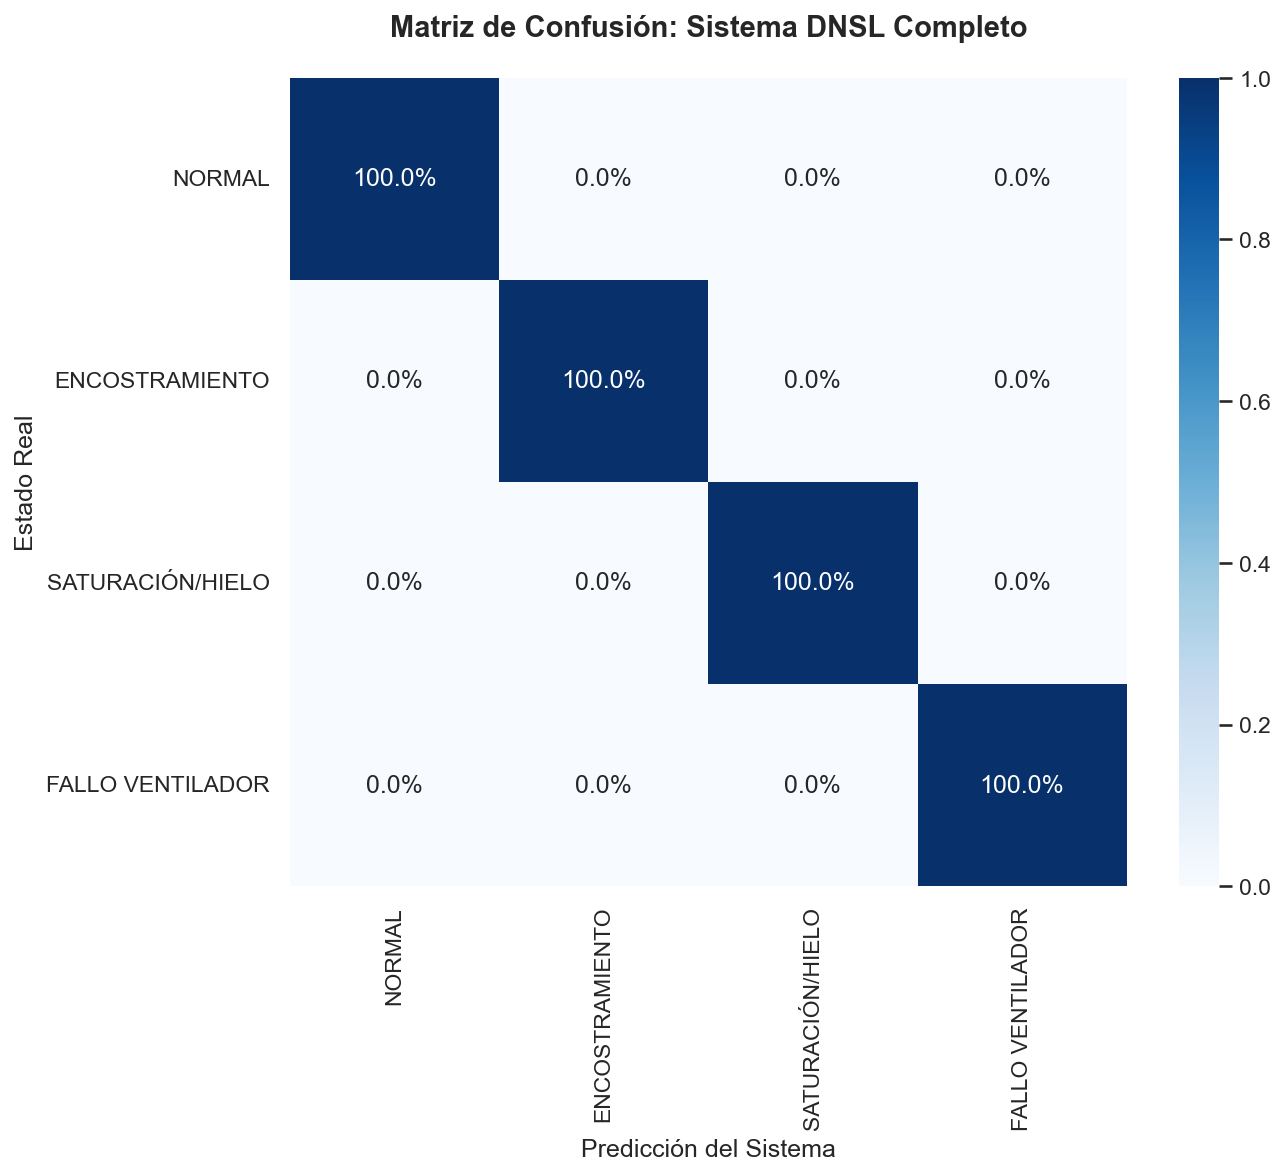

In [39]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels = [target_mapping[i] for i in sorted(target_mapping.keys())]
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm_perc, annot=True, fmt=".1%", cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Estado Real')
    plt.xlabel('Predicción del Sistema')
    plt.show()

plot_confusion_matrix(y_test, y_pred_final, "Matriz de Confusión: Sistema DNSL Completo")

=== COMPARATIVA DE ROBUSTEZ: EFECTO DEL VOTO POR RUN ===
            Métrica Modelo Puro (Fila a Fila) Modelo con Voto por Run
           Accuracy                    0.9567                  1.0000
F1-Score (Weighted)                    0.9586                  1.0000


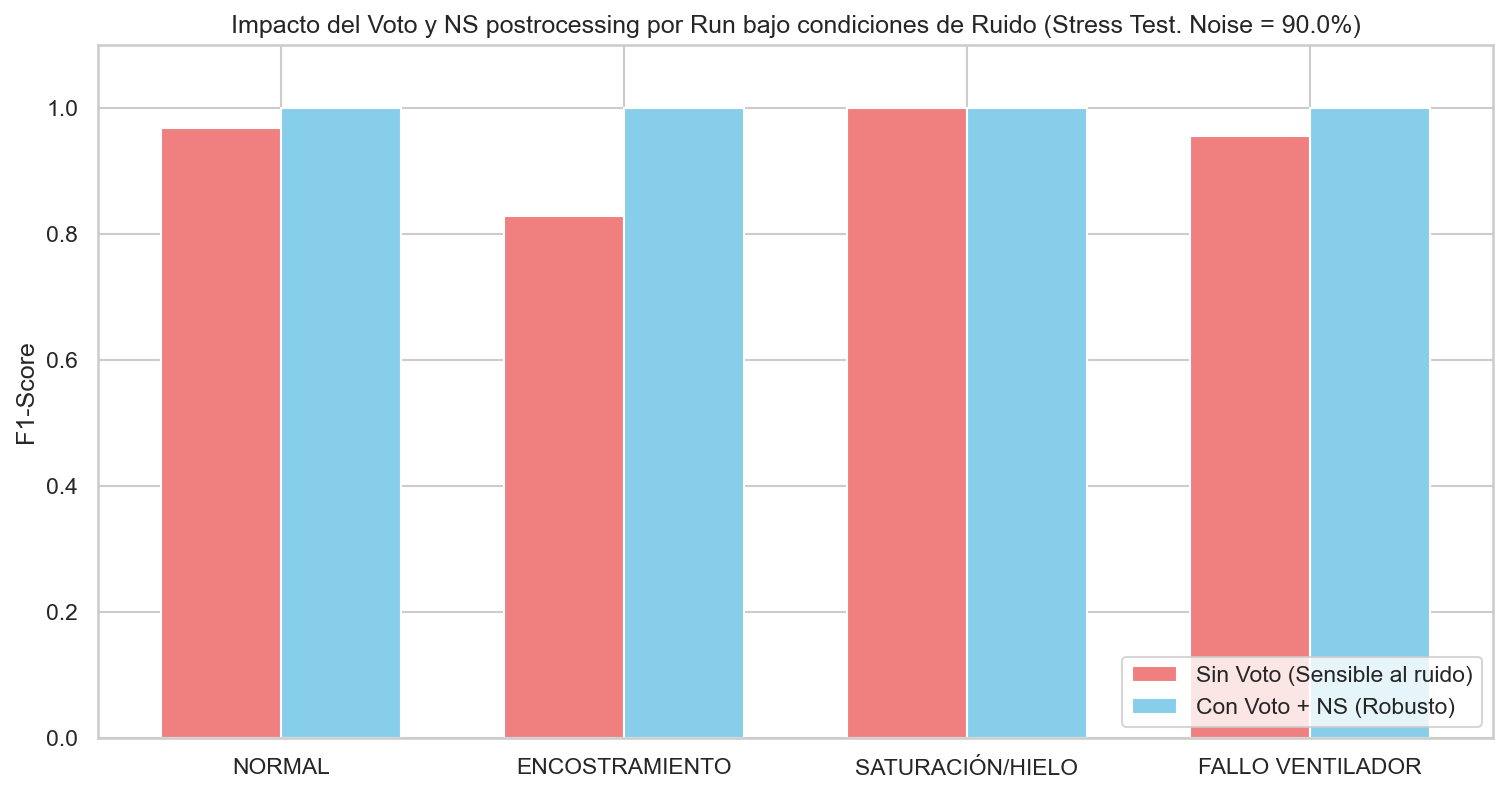

In [47]:
from sklearn.metrics import accuracy_score, f1_score

def compare_voting_robustness(y_true, y_pred_pure, y_pred_voted, target_names):
    # Calcular métricas para ambos
    acc_pure = accuracy_score(y_true, y_pred_pure)
    acc_voted = accuracy_score(y_true, y_pred_voted)
    f1_pure = f1_score(y_true, y_pred_pure, average='weighted')
    f1_voted = f1_score(y_true, y_pred_voted, average='weighted')
    
    # Crear tabla comparativa
    results = pd.DataFrame({
        'Métrica': ['Accuracy', 'F1-Score (Weighted)'],
        'Modelo Puro (Fila a Fila)': [f"{acc_pure:.4f}", f"{f1_pure:.4f}"],
        'Modelo con Voto por Run': [f"{acc_voted:.4f}", f"{f1_voted:.4f}"]
    })
    
    print("=== COMPARATIVA DE ROBUSTEZ: EFECTO DEL VOTO POR RUN ===")
    print(results.to_string(index=False))
    
    # Visualización de la degradación por clase
    report_pure = classification_report(y_true, y_pred_pure, target_names=target_names, output_dict=True)
    report_voted = classification_report(y_true, y_pred_voted, target_names=target_names, output_dict=True)
    
    f1_by_class_pure = [report_pure[name]['f1-score'] for name in target_names]
    f1_by_class_voted = [report_voted[name]['f1-score'] for name in target_names]
    
    x = np.arange(len(target_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, f1_by_class_pure, width, label='Sin Voto (Sensible al ruido)', color='lightcoral')
    ax.bar(x + width/2, f1_by_class_voted, width, label='Con Voto + NS (Robusto)', color='skyblue')
    
    ax.set_ylabel('F1-Score')
    ax.set_title(f'Impacto del Voto y NS postrocessing por Run bajo condiciones de Ruido (Stress Test. Noise = {noise_level*100}%)')
    ax.set_xticks(x)
    ax.set_xticklabels(target_names)
    ax.legend(loc = 'lower right')
    ax.set_ylim(0, 1.1)
    
    plt.show()

# Ejecutar la comparativa 
compare_voting_robustness(
    y_test, 
    y_pred_noisy, 
    y_voted_ns_noisy, 
    target_names=list(target_mapping.values())
)

In [48]:
print("--- REPORTE DETALLADO POR CLASE (SISTEMA FINAL) ---")
print(classification_report(y_test, y_pred_final, target_names=list(target_mapping.values())))

--- REPORTE DETALLADO POR CLASE (SISTEMA FINAL) ---
                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00      1720
  ENCOSTRAMIENTO       1.00      1.00      1.00       200
SATURACIÓN/HIELO       1.00      1.00      1.00       200
FALLO VENTILADOR       1.00      1.00      1.00       280

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



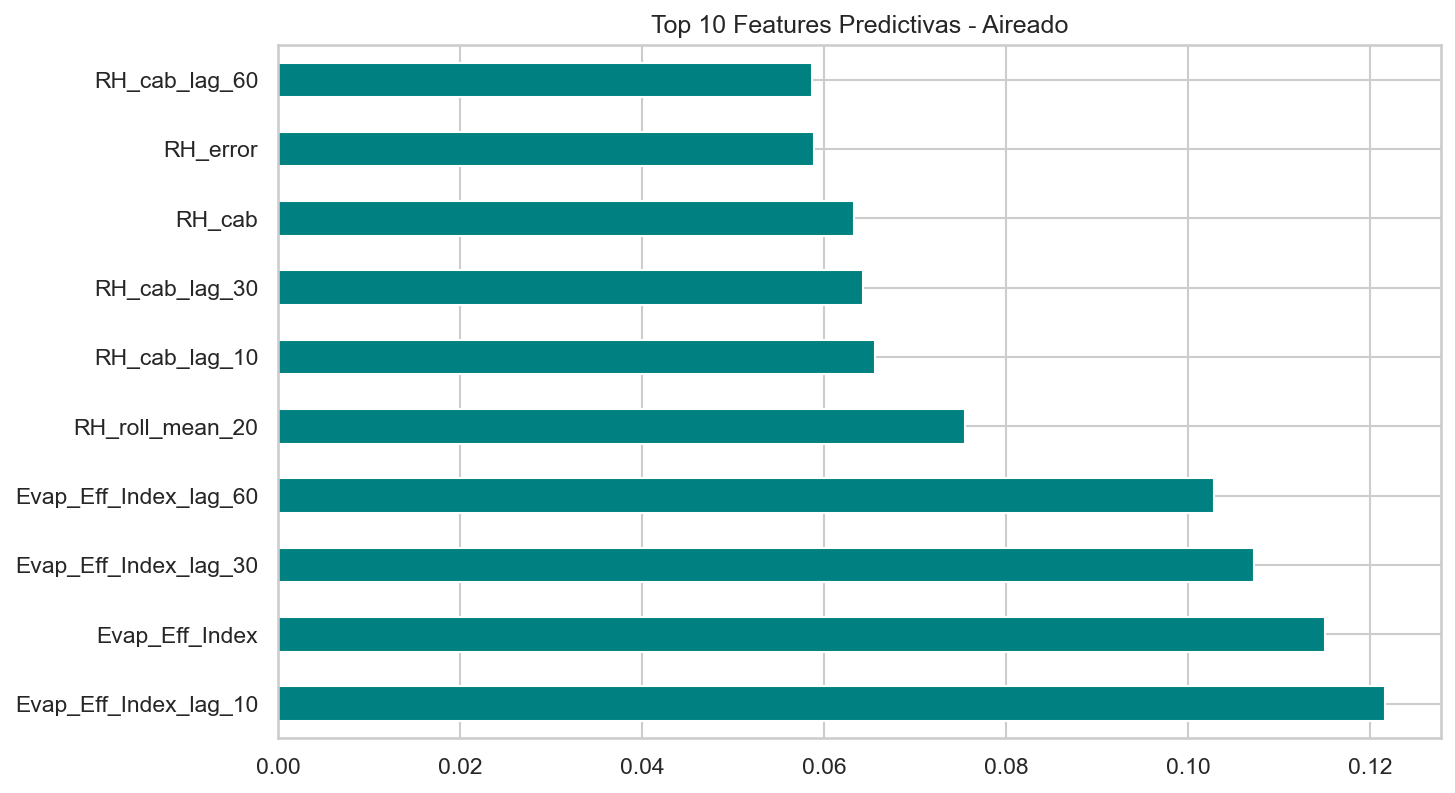

In [49]:
#Feature importances
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='teal')
plt.title("Top 10 Features Predictivas - Aireado")
plt.show()